In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer


In [3]:
df = pd.read_excel(r"C:\Users\lesson\OneDrive\Desktop\YIELD\Zimbabwe_Maize_Yield_Dataset.xlsx")
df.head()

,Season,Year,Province,Agro Ecological Zone,Farming Scale,Maize Variety,Area Cultivated ha,Seasonal Rainfall mm,Avg Max Temp C,Avg Min Temp C,...,Soil Type,Soil pH,Soil Nitrogen pct,Soil Organic Matter pct,Fertilizer kg ha,Irrigation,Improved Seed,Pesticide Used,Planting Date Delay days,Maize Yield kg ha
0,2005/2006,2005,Mashonaland West,II,Smallholder,ZM521,2.92,825.6,29.8,24.8,...,Sandy Loam,6.9,0.23,2.62,2.5,0,0,0,20,2624.8
1,2005/2006,2005,Mashonaland West,II,Smallholder,Local/OPV,2.20,614.0,28.7,24.7,...,Clay Loam,6.0,0.34,1.90,103.2,0,0,1,13,2885.6
2,2005/2006,2005,Mashonaland West,II,Smallholder,DKC80-73,1.28,643.3,27.2,24.0,...,Clay Loam,5.3,0.32,1.28,79.5,0,1,0,17,3215.1
3,2005/2006,2005,Mashonaland West,II,Smallholder,ZM421,0.85,805.5,29.1,24.0,...,Sandy Loam,6.9,0.16,1.34,65.1,0,0,1,23,2689.3
4,2005/2006,2005,Mashonaland West,II,Smallholder,Local/OPV,1.43,666.0,28.8,25.7,...,Sandy,7.0,0.31,1.85,11.4,0,1,1,21,3335.4


In [4]:
print("Shape:", df.shape)
print("\nColumn Types & Null Counts:")
print(pd.DataFrame({
    'dtype':    df.dtypes,
    'nulls':    df.isnull().sum(),
    'pct_null': (df.isnull().sum() / len(df) * 100).round(2)
}).to_string())

Shape: (8056, 22)

Column Types & Null Counts:
                            dtype  nulls  pct_null
Season                     object      0       0.0
Year                        int64      0       0.0
Province                   object      0       0.0
Agro Ecological Zone       object      0       0.0
Farming Scale              object      0       0.0
Maize Variety              object      0       0.0
Area Cultivated ha        float64      0       0.0
Seasonal Rainfall mm      float64      0       0.0
Avg Max Temp C            float64      0       0.0
Avg Min Temp C            float64      0       0.0
ENSO Index                float64      0       0.0
Drought Year                int64      0       0.0
Soil Type                  object      0       0.0
Soil pH                   float64      0       0.0
Soil Nitrogen pct         float64      0       0.0
Soil Organic Matter pct   float64      0       0.0
Fertilizer kg ha          float64      0       0.0
Irrigation                  int64  

In [5]:
print("\nNumeric Summary:")
print(df.describe().round(2).T.to_string())


Numeric Summary:
                           count     mean      std      min      25%      50%      75%       max
Year                      8056.0  2014.00     5.48  2005.00  2009.00  2014.00  2019.00   2023.00
Area Cultivated ha        8056.0    28.09    63.00     0.50     1.61     2.69    14.10    299.37
Seasonal Rainfall mm      8056.0   557.80   172.29   164.90   424.40   550.00   679.82   1083.20
Avg Max Temp C            8056.0    28.50     3.27    18.00    27.00    28.70    30.70     37.60
Avg Min Temp C            8056.0    25.63     2.96    16.20    24.20    25.70    27.60     33.20
ENSO Index                8056.0     0.48     1.06    -0.43    -0.33    -0.05     1.91      2.36
Drought Year              8056.0     0.26     0.44     0.00     0.00     0.00     1.00      1.00
Soil pH                   8056.0     6.21     0.58     5.20     5.70     6.20     6.70      7.20
Soil Nitrogen pct         8056.0     0.20     0.09     0.05     0.13     0.20     0.28      0.35
Soil Organic

In [6]:
print("\nCategorical Columns:")
for c in df.select_dtypes('object').columns:
    print(f"  {c} ({df[c].nunique()} unique): {df[c].unique().tolist()}")



Categorical Columns:
  Season (19 unique): ['2005/2006', '2006/2007', '2007/2008', '2008/2009', '2009/2010', '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018/2019', '2019/2020', '2020/2021', '2021/2022', '2022/2023', '2023/2024']
  Province (8 unique): ['Mashonaland West', 'Mashonaland East', 'Mashonaland Central', 'Manicaland', 'Masvingo', 'Midlands', 'Matabeleland North', 'Matabeleland South']
  Agro Ecological Zone (6 unique): ['II', 'IIb', 'I', 'IV', 'III', 'V']
  Farming Scale (3 unique): ['Smallholder', 'Small Commercial', 'Large Commercial']
  Maize Variety (6 unique): ['ZM521', 'Local/OPV', 'DKC80-73', 'ZM421', 'SC513', 'SC403']
  Soil Type (4 unique): ['Sandy Loam', 'Clay Loam', 'Sandy', 'Red Clay']


In [7]:
TARGET = 'Maize Yield kg ha'
print("\nTarget — Maize Yield (kg/ha):")
print(f"  Mean:   {df[TARGET].mean():.1f}")
print(f"  Median: {df[TARGET].median():.1f}")
print(f"  Std:    {df[TARGET].std():.1f}")
print(f"  Skew:   {df[TARGET].skew():.3f}")
print(f"  Min:    {df[TARGET].min():.1f}  |  Max: {df[TARGET].max():.1f}")


Target — Maize Yield (kg/ha):
  Mean:   3300.6
  Median: 2831.6
  Std:    1962.2
  Skew:   1.254
  Min:    200.0  |  Max: 12236.2


In [8]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [9]:
palette = ['#1F4E79','#2E75B6','#5BA3D9','#A9D1F7','#F4A261','#E76F51','#2A9D8F','#264653']
sns.set_style('whitegrid')

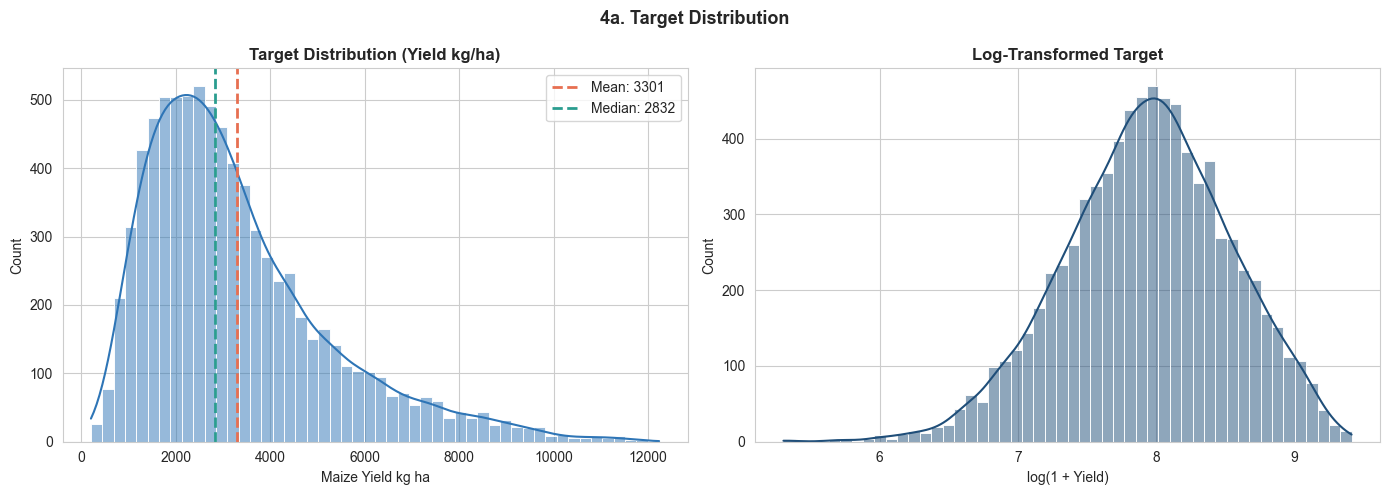

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[TARGET], bins=50, kde=True, color='#2E75B6', ax=axes[0])
axes[0].axvline(df[TARGET].mean(), color='#E76F51', lw=2, ls='--', label=f'Mean: {df[TARGET].mean():.0f}')
axes[0].axvline(df[TARGET].median(), color='#2A9D8F', lw=2, ls='--', label=f'Median: {df[TARGET].median():.0f}')
axes[0].set_title('Target Distribution (Yield kg/ha)', fontweight='bold')
axes[0].legend()

sns.histplot(np.log1p(df[TARGET]), bins=50, kde=True, color='#1F4E79', ax=axes[1])
axes[1].set_title('Log-Transformed Target', fontweight='bold')
axes[1].set_xlabel('log(1 + Yield)')

plt.suptitle('4a. Target Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

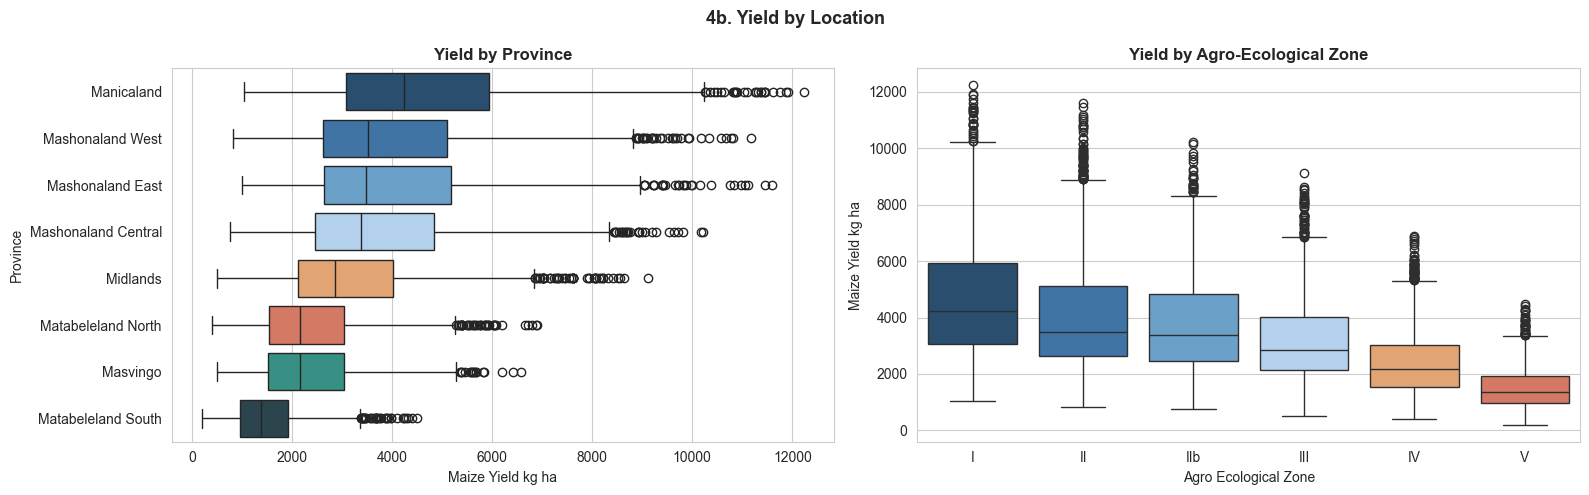

In [11]:
# 4b. Yield by Province & AEZ
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

prov_order = df.groupby('Province')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x=TARGET, y='Province', order=prov_order, palette=palette, ax=axes[0])
axes[0].set_title('Yield by Province', fontweight='bold')

sns.boxplot(data=df, x='Agro Ecological Zone', y=TARGET,
            order=['I','II','IIb','III','IV','V'], palette=palette, ax=axes[1])
axes[1].set_title('Yield by Agro-Ecological Zone', fontweight='bold')

plt.suptitle('4b. Yield by Location', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

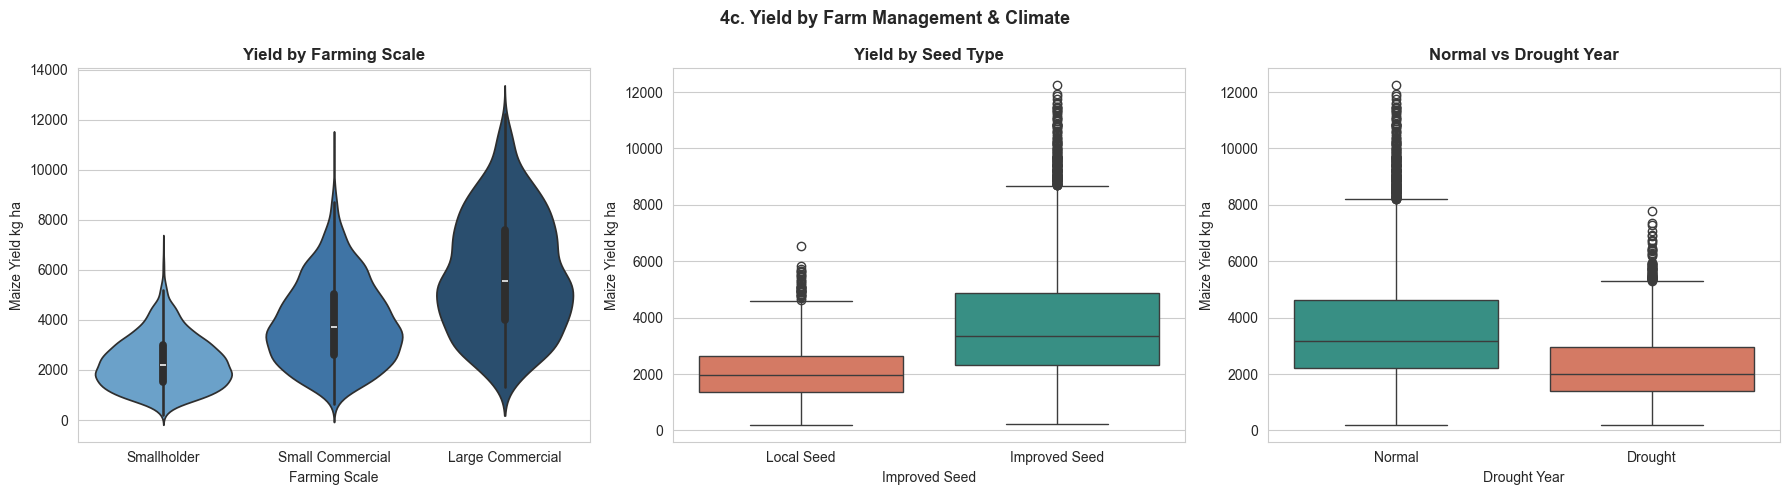

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(data=df, x='Farming Scale', y=TARGET,
               order=['Smallholder','Small Commercial','Large Commercial'],
               palette=['#5BA3D9','#2E75B6','#1F4E79'], ax=axes[0])
axes[0].set_title('Yield by Farming Scale', fontweight='bold')

sns.boxplot(data=df, x='Improved Seed', y=TARGET,
            palette=['#E76F51','#2A9D8F'], ax=axes[1])
axes[1].set_xticklabels(['Local Seed','Improved Seed'])
axes[1].set_title('Yield by Seed Type', fontweight='bold')

sns.boxplot(data=df, x='Drought Year', y=TARGET,
            palette=['#2A9D8F','#E76F51'], ax=axes[2])
axes[2].set_xticklabels(['Normal','Drought'])
axes[2].set_title('Normal vs Drought Year', fontweight='bold')

plt.suptitle('4c. Yield by Farm Management & Climate', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

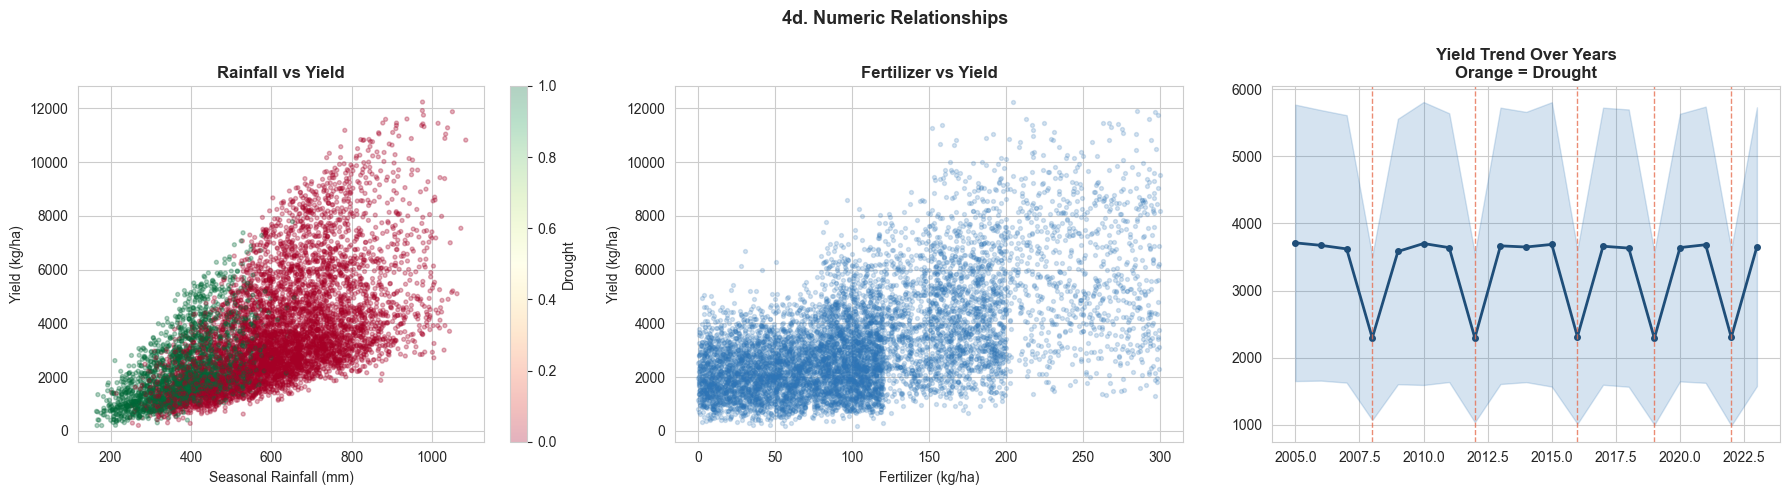

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc = axes[0].scatter(df['Seasonal Rainfall mm'], df[TARGET],
                     c=df['Drought Year'], cmap='RdYlGn', alpha=0.3, s=8)
plt.colorbar(sc, ax=axes[0], label='Drought')
axes[0].set_xlabel('Seasonal Rainfall (mm)')
axes[0].set_ylabel('Yield (kg/ha)')
axes[0].set_title('Rainfall vs Yield', fontweight='bold')

axes[1].scatter(df['Fertilizer kg ha'], df[TARGET], alpha=0.2, s=8, color='#2E75B6')
axes[1].set_xlabel('Fertilizer (kg/ha)')
axes[1].set_ylabel('Yield (kg/ha)')
axes[1].set_title('Fertilizer vs Yield', fontweight='bold')

yr = df.groupby('Year')[TARGET].agg(['mean','std']).reset_index()
axes[2].plot(yr['Year'], yr['mean'], color='#1F4E79', lw=2, marker='o', ms=4)
axes[2].fill_between(yr['Year'], yr['mean']-yr['std'], yr['mean']+yr['std'], alpha=0.2, color='#2E75B6')
for dy in [2008,2012,2016,2019,2022]:
    axes[2].axvline(dy, color='#E76F51', lw=1, ls='--', alpha=0.8)
axes[2].set_title('Yield Trend Over Years\nOrange = Drought', fontweight='bold')

plt.suptitle('4d. Numeric Relationships', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


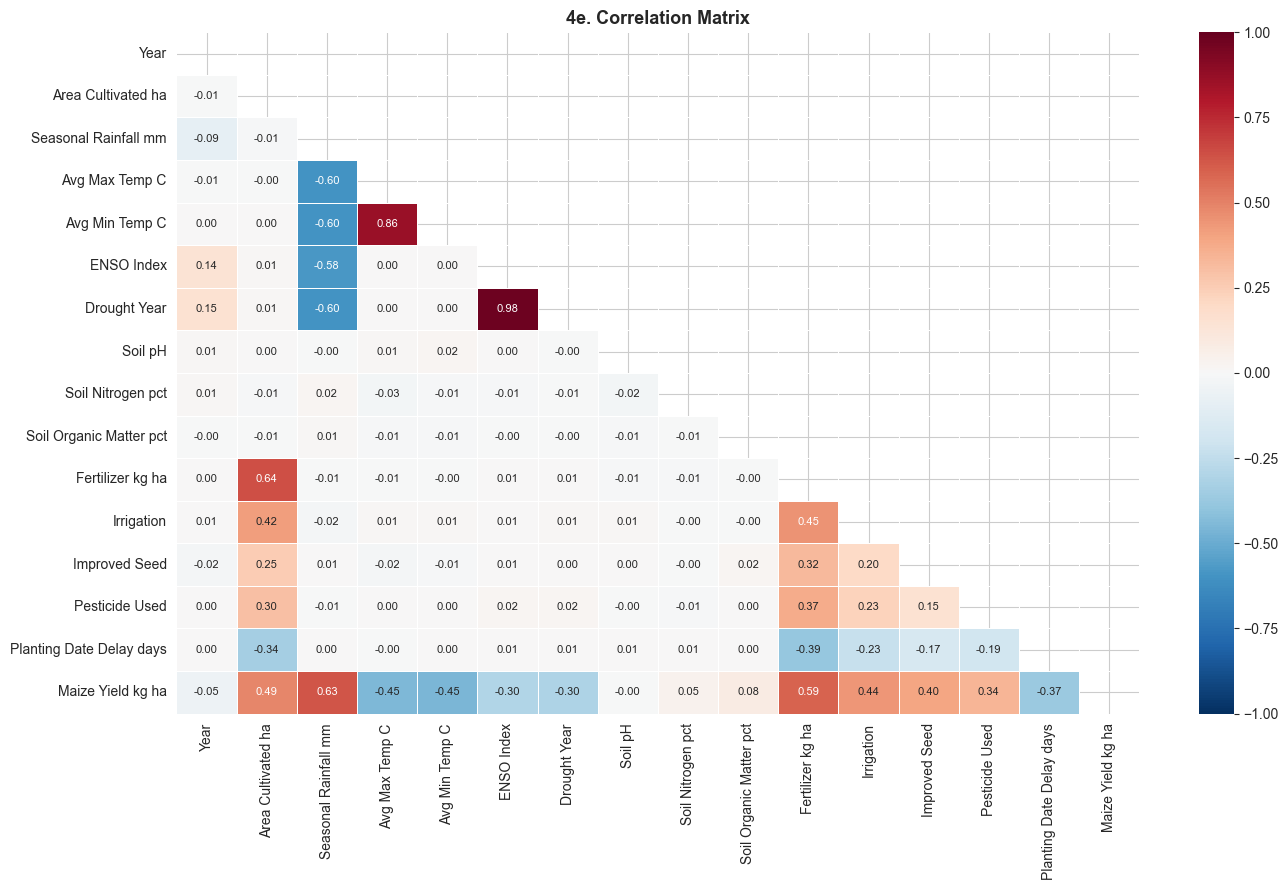

In [14]:
fig, ax = plt.subplots(figsize=(14, 9))
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, annot_kws={'size': 8}, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('4e. Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
df_model = df.drop(columns=[
    'Season',           # non-predictive identifier
    'Year',             # no meaningful time trend (corr = -0.05)
    'ENSO Index',       # 0.98 collinear with Drought Year
    'Avg Min Temp C',   # 0.86 collinear with Avg Max Temp C
])

In [16]:
aez_map = {'I': 1, 'II': 2, 'IIb': 3, 'III': 3, 'IV': 4, 'V': 5}
df_model['AEZ_Ordinal'] = df_model['Agro Ecological Zone'].map(aez_map)
df_model = df_model.drop(columns=['Agro Ecological Zone'])

In [17]:
X     = df_model.drop(columns=[TARGET])
y_raw = df_model[TARGET]
y     = np.log1p(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
cat_cols = ['Province', 'Farming Scale', 'Maize Variety', 'Soil Type']
num_cols = [c for c in X.columns if c not in cat_cols]

# 6c. Preprocessing within pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [19]:
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge':              Ridge(alpha=1.0),
    'Lasso':              Lasso(alpha=0.01),
    'Decision Tree':      DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=15,
                                                min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Extra Trees':        ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                     max_depth=5, random_state=42),
    'XGBoost':            xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                            max_depth=6, random_state=42,
                                            eval_metric='rmse', verbosity=0),
}

In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<25} | {'CV R² Mean':>10} | {'CV R² Std':>10} | {'Test R²':>8} | {'RMSE':>8} | {'MAE':>8}")
print("-" * 80)

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model',        model)
    ])

    # Cross-validation
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=kf,
                                scoring='r2', n_jobs=-1)

    # Fit & predict
    pipe.fit(X_train, y_train)
    y_pred_log = pipe.predict(X_test)

    # Back-transform
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    results[name] = {
        'CV R² Mean': round(cv_scores.mean(), 4),
        'CV R² Std':  round(cv_scores.std(),  4),
        'Test R²':    round(r2,   4),
        'Test RMSE':  round(rmse, 2),
        'Test MAE':   round(mae,  2),
        'pipeline':   pipe
    }

    print(f"{name:<25} | {cv_scores.mean():>10.4f} | {cv_scores.std():>10.4f} | {r2:>8.4f} | {rmse:>8.1f} | {mae:>8.1f}")


Model                     | CV R² Mean |  CV R² Std |  Test R² |     RMSE |      MAE
--------------------------------------------------------------------------------
Linear Regression         |     0.9590 |     0.0019 |   0.9777 |    293.2 |    222.8
Ridge                     |     0.9590 |     0.0019 |   0.9777 |    293.2 |    222.8
Lasso                     |     0.9459 |     0.0020 |   0.9543 |    419.9 |    302.8
Decision Tree             |     0.8918 |     0.0065 |   0.9380 |    489.3 |    369.0
Random Forest             |     0.9426 |     0.0028 |   0.9675 |    354.1 |    270.8
Extra Trees               |     0.9457 |     0.0019 |   0.9738 |    317.9 |    247.5
Gradient Boosting         |     0.9607 |     0.0019 |   0.9836 |    251.5 |    199.2
XGBoost                   |     0.9592 |     0.0024 |   0.9830 |    256.3 |    201.8


In [21]:
print("\nFull Results (sorted by Test R²):")
results_df = (pd.DataFrame(results).T
                .drop(columns='pipeline')
                .astype(float)
                .sort_values('Test R²', ascending=False))
print(results_df.to_string())

best_name = results_df['Test R²'].idxmax()
print(f"\nBest model: {best_name} — Test R²: {results_df.loc[best_name, 'Test R²']}")


Full Results (sorted by Test R²):
                   CV R² Mean  CV R² Std  Test R²  Test RMSE  Test MAE
Gradient Boosting      0.9607     0.0019   0.9836     251.50    199.17
XGBoost                0.9592     0.0024   0.9830     256.25    201.83
Linear Regression      0.9590     0.0019   0.9777     293.17    222.76
Ridge                  0.9590     0.0019   0.9777     293.19    222.77
Extra Trees            0.9457     0.0019   0.9738     317.88    247.51
Random Forest          0.9426     0.0028   0.9675     354.08    270.76
Lasso                  0.9459     0.0020   0.9543     419.94    302.85
Decision Tree          0.8918     0.0065   0.9380     489.26    368.99

Best model: Gradient Boosting — Test R²: 0.9836


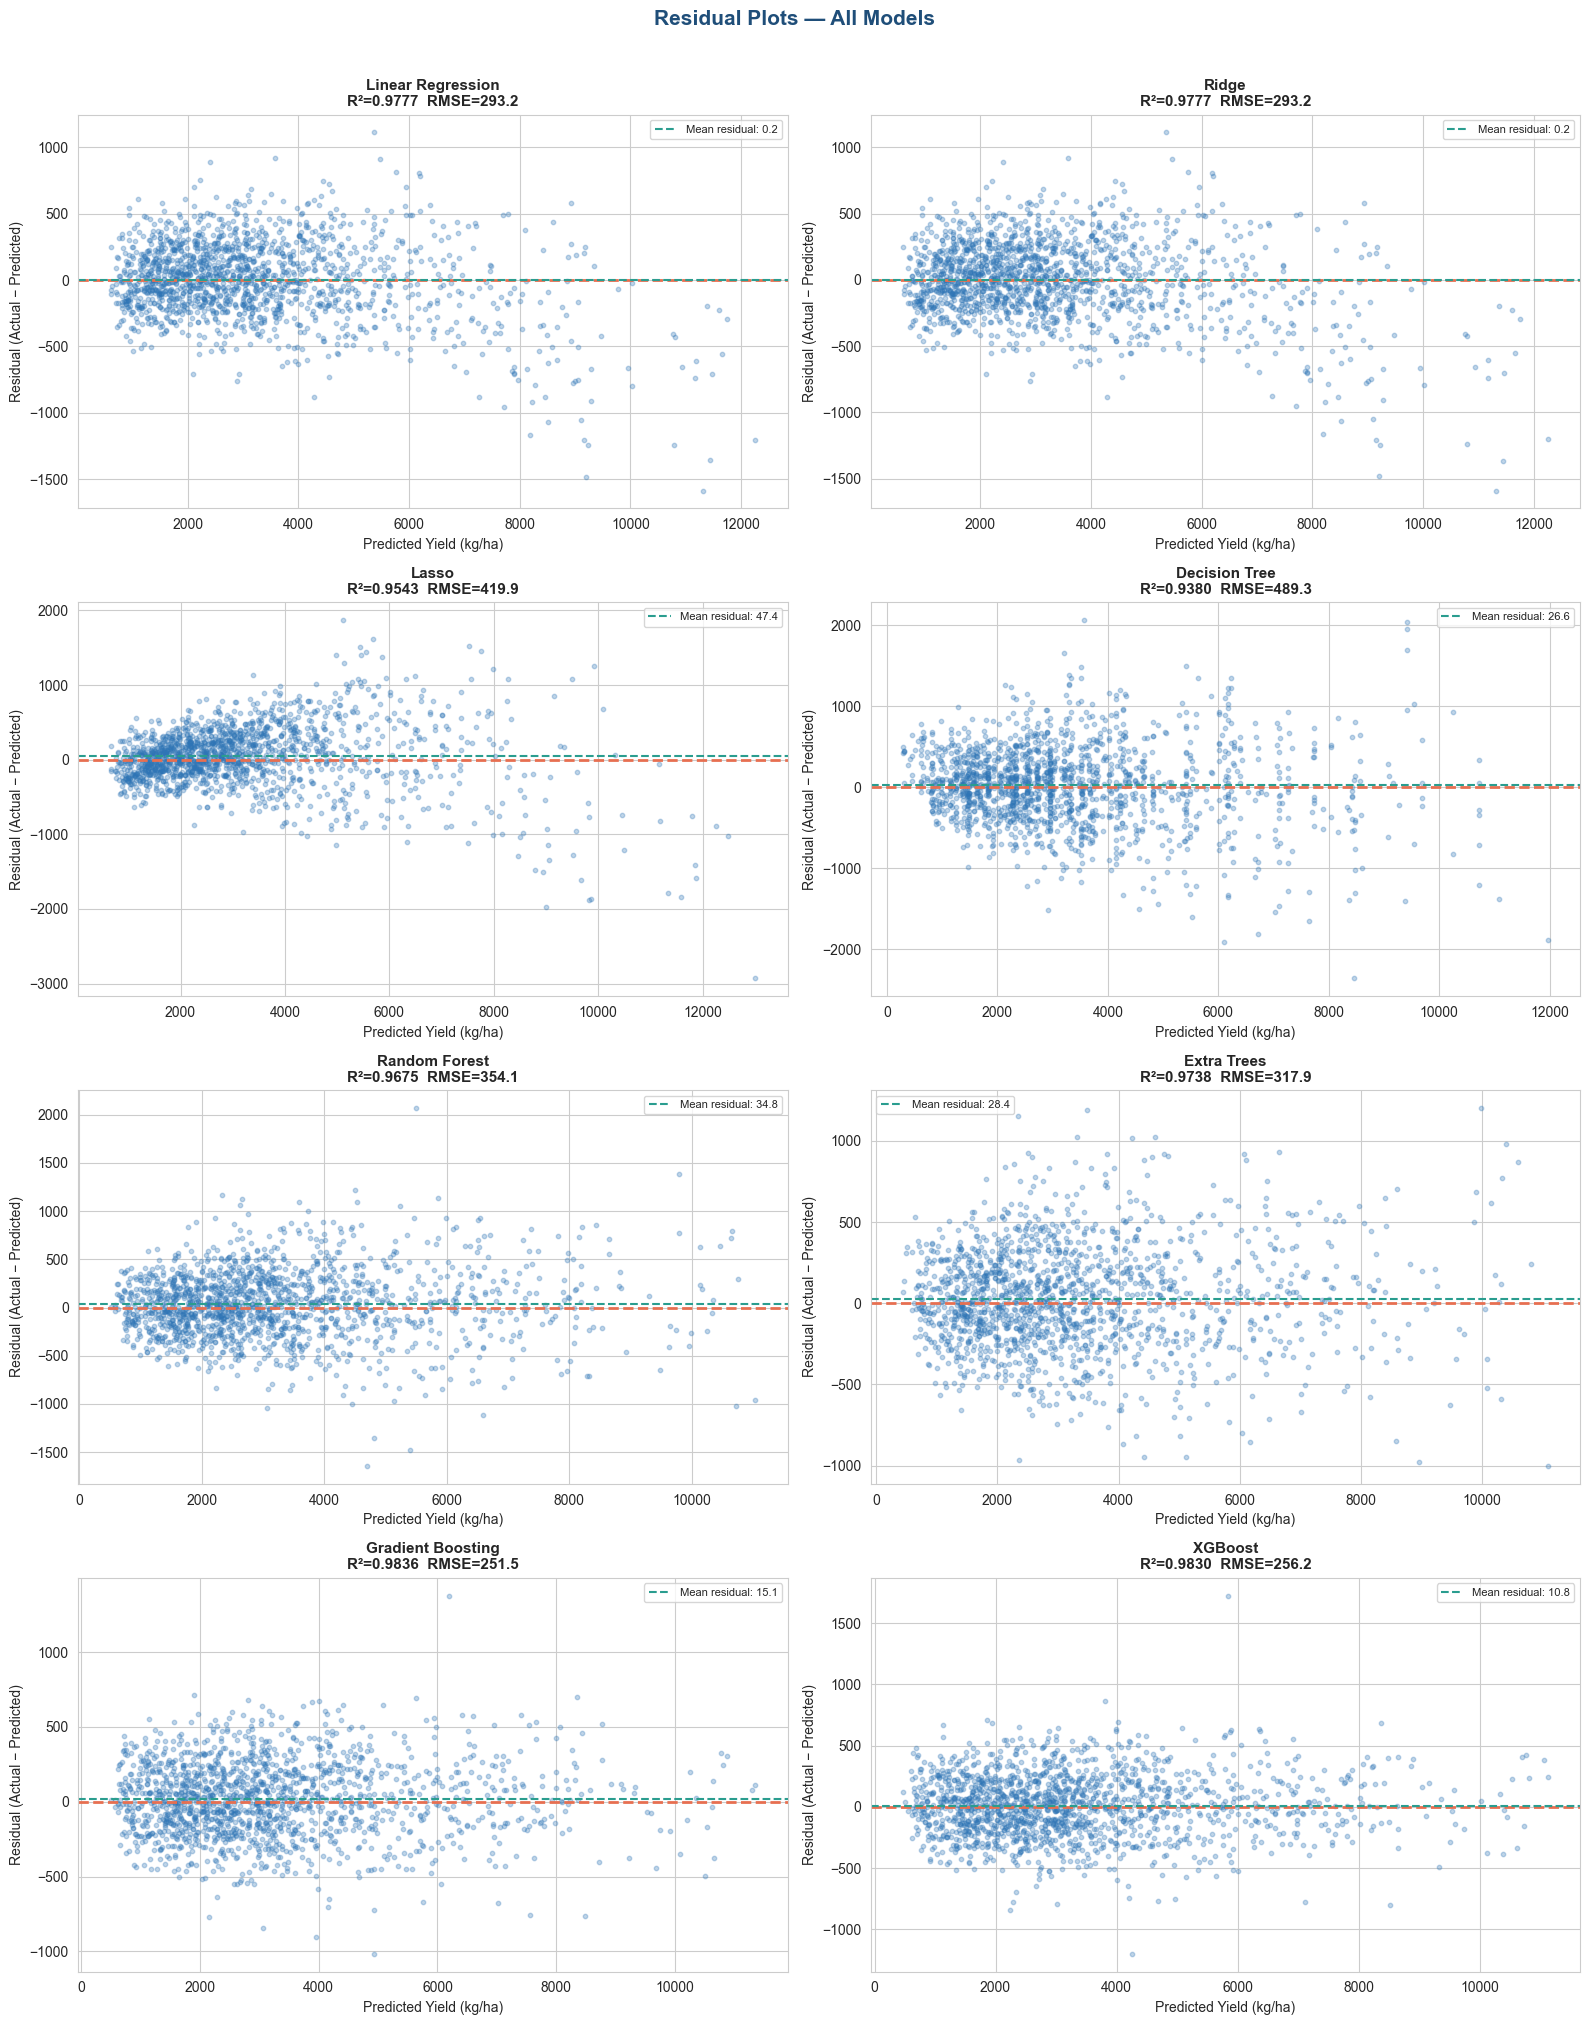

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    pipe   = res['pipeline']
    y_pred = np.expm1(pipe.predict(X_test))
    y_true = np.expm1(y_test)
    resids = y_true - y_pred

    ax = axes[idx]
    ax.scatter(y_pred, resids, alpha=0.3, s=10, color='#2E75B6')
    ax.axhline(0, color='#E76F51', lw=2, ls='--')
    ax.axhline(resids.mean(), color='#2A9D8F', lw=1.5, ls='--',
               label=f'Mean residual: {resids.mean():.1f}')
    ax.set_title(f'{name}\nR²={res["Test R²"]:.4f}  RMSE={res["Test RMSE"]:.1f}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Yield (kg/ha)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.legend(fontsize=8)

plt.suptitle('Residual Plots — All Models', fontsize=15, fontweight='bold',
             color='#1F4E79', y=1.01)
plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
best_name = 'Gradient Boosting'
best_pipe = results[best_name]['pipeline']

# 8a. Extract feature names after OHE
ohe_features = (best_pipe.named_steps['preprocessor']
                          .named_transformers_['cat']
                          .named_steps['ohe']
                          .get_feature_names_out(cat_cols).tolist())
all_features = num_cols + ohe_features

In [24]:
importances = best_pipe.named_steps['model'].feature_importances_
feat_imp = (pd.Series(importances, index=all_features)
              .sort_values(ascending=False))


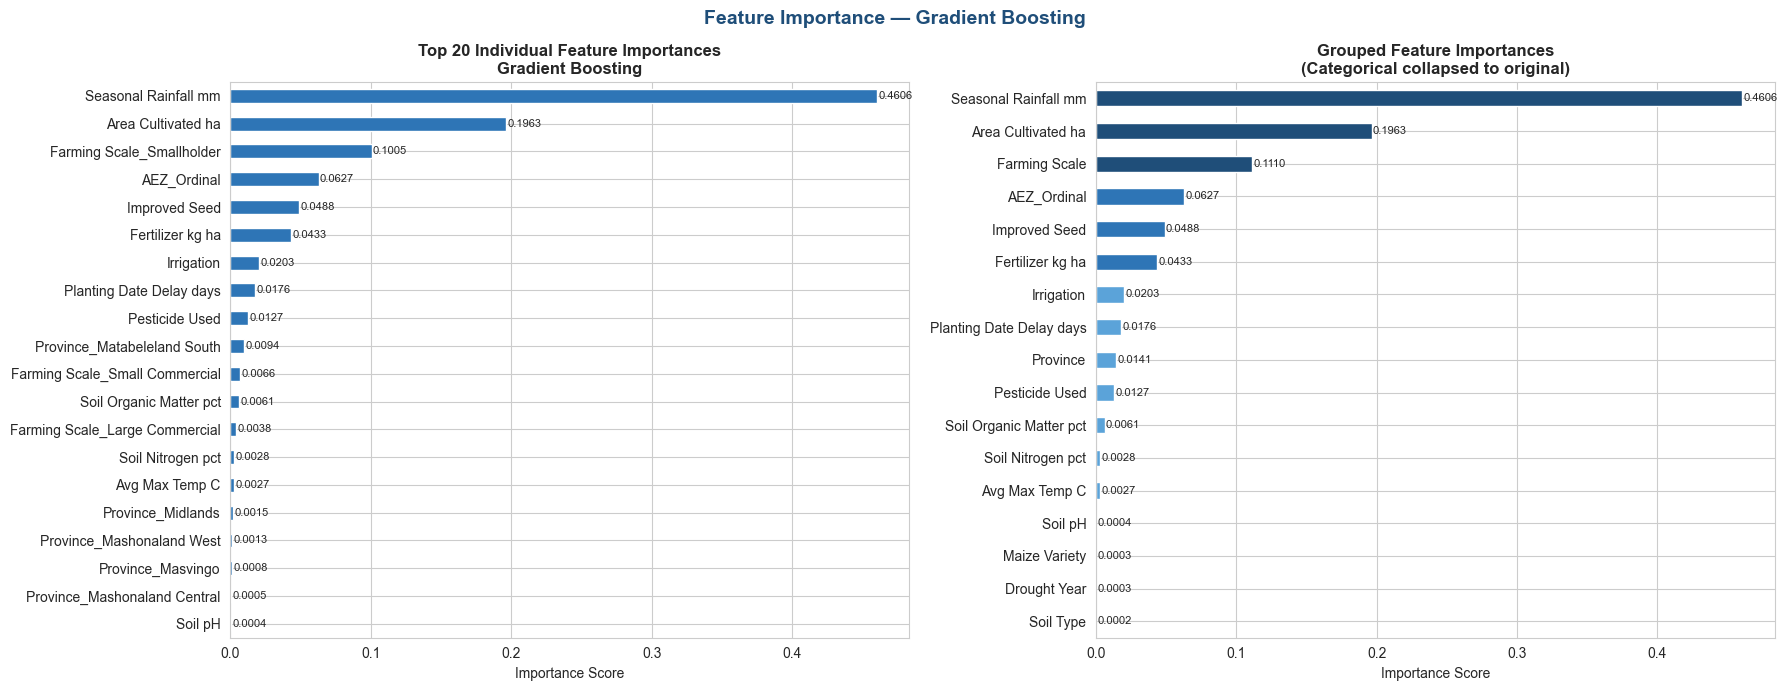

Grouped Feature Importance Ranking:
----------------------------------------
   1. Seasonal Rainfall mm                0.4606
   2. Area Cultivated ha                  0.1963
   3. Farming Scale                       0.1110
   4. AEZ_Ordinal                         0.0627
   5. Improved Seed                       0.0488
   6. Fertilizer kg ha                    0.0433
   7. Irrigation                          0.0203
   8. Planting Date Delay days            0.0176
   9. Province                            0.0141
  10. Pesticide Used                      0.0127
  11. Soil Organic Matter pct             0.0061
  12. Soil Nitrogen pct                   0.0028
  13. Avg Max Temp C                      0.0027
  14. Soil pH                             0.0004
  15. Maize Variety                       0.0003
  16. Drought Year                        0.0003
  17. Soil Type                           0.0002


In [25]:
# 8c. Top 20 — individual features
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

feat_imp.head(20).plot(kind='barh', ax=axes[0], color='#2E75B6')
axes[0].invert_yaxis()
axes[0].set_title('Top 20 Individual Feature Importances\nGradient Boosting',
                   fontweight='bold', fontsize=12)
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(feat_imp.head(20)):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

# 8d. Grouped importances — collapse OHE back to original feature
def group_importance(feat_imp, cat_cols, num_cols):
    grouped = {}
    for f, v in feat_imp.items():
        matched = False
        for c in cat_cols:
            if f.startswith(c):
                grouped[c] = grouped.get(c, 0) + v
                matched = True
                break
        if not matched:
            grouped[f] = v
    return pd.Series(grouped).sort_values(ascending=False)

grouped_imp = group_importance(feat_imp, cat_cols, num_cols)

colors = ['#1F4E79' if i < 3 else '#2E75B6' if i < 6 else '#5BA3D9'
          for i in range(len(grouped_imp))]
grouped_imp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].invert_yaxis()
axes[1].set_title('Grouped Feature Importances\n(Categorical collapsed to original)',
                   fontweight='bold', fontsize=12)
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(grouped_imp):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Feature Importance — Gradient Boosting', fontsize=14,
             fontweight='bold', color='#1F4E79')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 8e. Print grouped ranking
print("Grouped Feature Importance Ranking:")
print("-" * 40)
for rank, (feat, score) in enumerate(grouped_imp.items(), 1):
    print(f"  {rank:>2}. {feat:<35} {score:.4f}")


In [26]:
selected_features = [
    'Seasonal Rainfall mm',
    'Area Cultivated ha',
    'Farming Scale',
    'AEZ_Ordinal',
    'Improved Seed',
    'Fertilizer kg ha',
    'Irrigation',
    'Planting Date Delay days',
    'Province',
    'Pesticide Used'
]

In [27]:
X_sel = df_model[selected_features]


In [28]:
cat_sel = [c for c in selected_features if c in cat_cols]
num_sel = [c for c in selected_features if c not in cat_cols]

print("Numeric:", num_sel)
print("Categorical:", cat_sel)


Numeric: ['Seasonal Rainfall mm', 'Area Cultivated ha', 'AEZ_Ordinal', 'Improved Seed', 'Fertilizer kg ha', 'Irrigation', 'Planting Date Delay days', 'Pesticide Used']
Categorical: ['Farming Scale', 'Province']


In [29]:
X_sel_train, X_sel_test, y_sel_train, y_sel_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42
)

In [30]:
sel_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), num_sel),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_sel)
])

In [31]:
sel_results = {}

print(f"\n{'Model':<25} | {'CV R² Mean':>10} | {'CV R² Std':>10} | {'Test R²':>8} | {'RMSE':>8} | {'MAE':>8}")
print("-" * 80)

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', sel_preprocessor),
        ('model',        model)
    ])

    cv_scores = cross_val_score(pipe, X_sel_train, y_sel_train,
                                cv=kf, scoring='r2', n_jobs=-1)

    pipe.fit(X_sel_train, y_sel_train)
    y_pred = np.expm1(pipe.predict(X_sel_test))
    y_true = np.expm1(y_sel_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    sel_results[name] = {
        'CV R² Mean': round(cv_scores.mean(), 4),
        'CV R² Std':  round(cv_scores.std(),  4),
        'Test R²':    round(r2,   4),
        'Test RMSE':  round(rmse, 2),
        'Test MAE':   round(mae,  2),
        'pipeline':   pipe
    }

    print(f"{name:<25} | {cv_scores.mean():>10.4f} | {cv_scores.std():>10.4f} | {r2:>8.4f} | {rmse:>8.1f} | {mae:>8.1f}")



Model                     | CV R² Mean |  CV R² Std |  Test R² |     RMSE |      MAE
--------------------------------------------------------------------------------
Linear Regression         |     0.9500 |     0.0017 |   0.9631 |    377.5 |    272.7
Ridge                     |     0.9500 |     0.0017 |   0.9631 |    377.4 |    272.7
Lasso                     |     0.9372 |     0.0018 |   0.9415 |    475.1 |    333.1
Decision Tree             |     0.9035 |     0.0029 |   0.9450 |    461.0 |    348.8
Random Forest             |     0.9417 |     0.0028 |   0.9660 |    362.5 |    277.2
Extra Trees               |     0.9462 |     0.0014 |   0.9722 |    327.4 |    256.0
Gradient Boosting         |     0.9547 |     0.0019 |   0.9766 |    300.5 |    235.5
XGBoost                   |     0.9534 |     0.0020 |   0.9758 |    305.5 |    240.0


In [32]:
print("\nComparison — Full Features vs Selected Features (Test R²):")
print(f"{'Model':<25} | {'Full R²':>8} | {'Selected R²':>11} | {'Diff':>8}")
print("-" * 60)
for name in models.keys():
    full_r2 = results[name]['Test R²']
    sel_r2  = sel_results[name]['Test R²']
    diff    = sel_r2 - full_r2
    print(f"{name:<25} | {full_r2:>8.4f} | {sel_r2:>11.4f} | {diff:>+8.4f}")


Comparison — Full Features vs Selected Features (Test R²):
Model                     |  Full R² | Selected R² |     Diff
------------------------------------------------------------
Linear Regression         |   0.9777 |      0.9631 |  -0.0146
Ridge                     |   0.9777 |      0.9631 |  -0.0146
Lasso                     |   0.9543 |      0.9415 |  -0.0128
Decision Tree             |   0.9380 |      0.9450 |  +0.0070
Random Forest             |   0.9675 |      0.9660 |  -0.0015
Extra Trees               |   0.9738 |      0.9722 |  -0.0016
Gradient Boosting         |   0.9836 |      0.9766 |  -0.0070
XGBoost                   |   0.9830 |      0.9758 |  -0.0072


In [33]:
import joblib

best_sel_name = 'Gradient Boosting'
best_sel_pipe = sel_results[best_sel_name]['pipeline']

y_pred_log = best_sel_pipe.predict(X_sel_test)
y_pred     = np.expm1(y_pred_log)
y_true     = np.expm1(y_sel_test)
resids     = y_true - y_pred


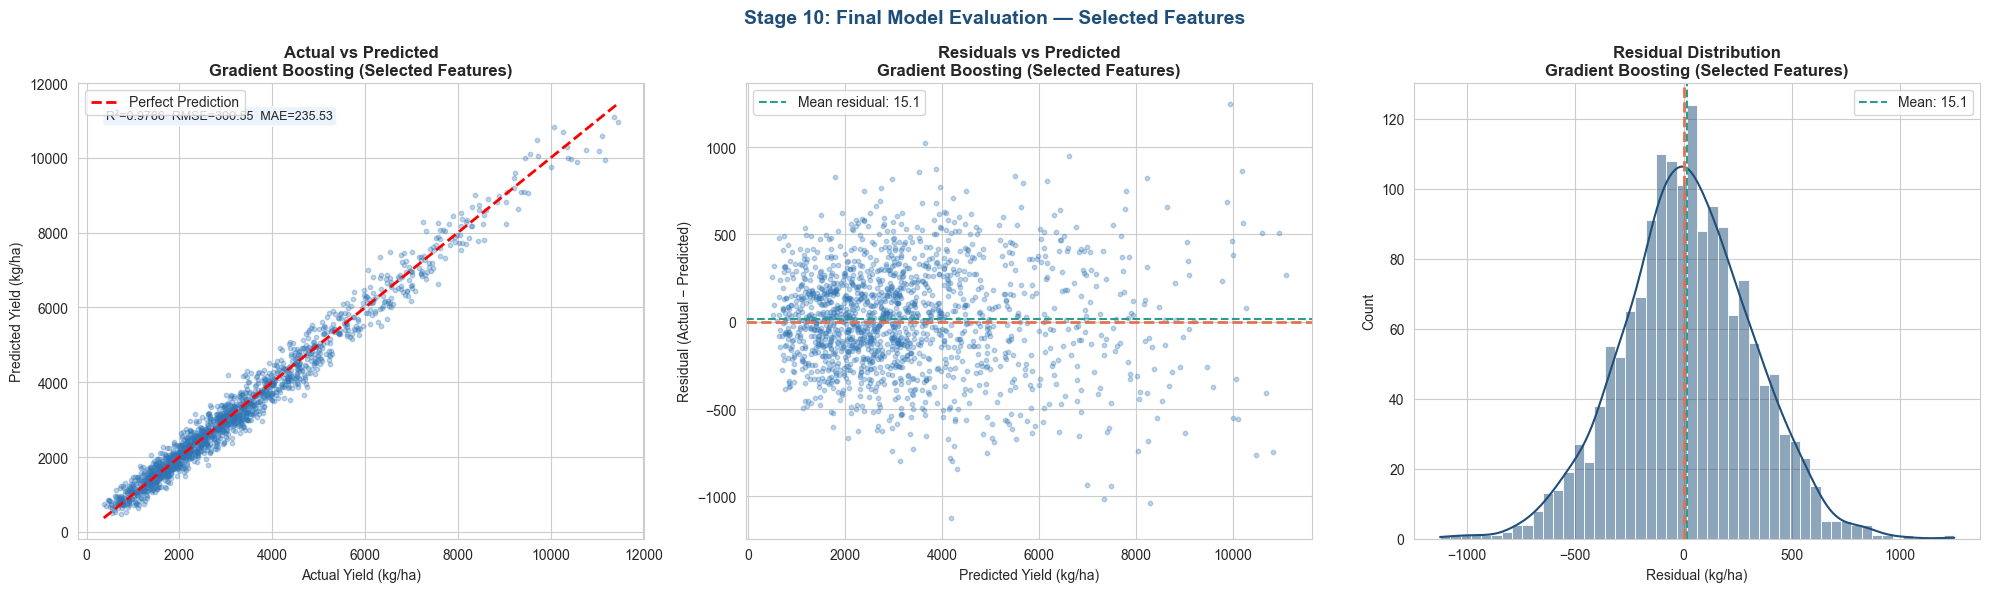

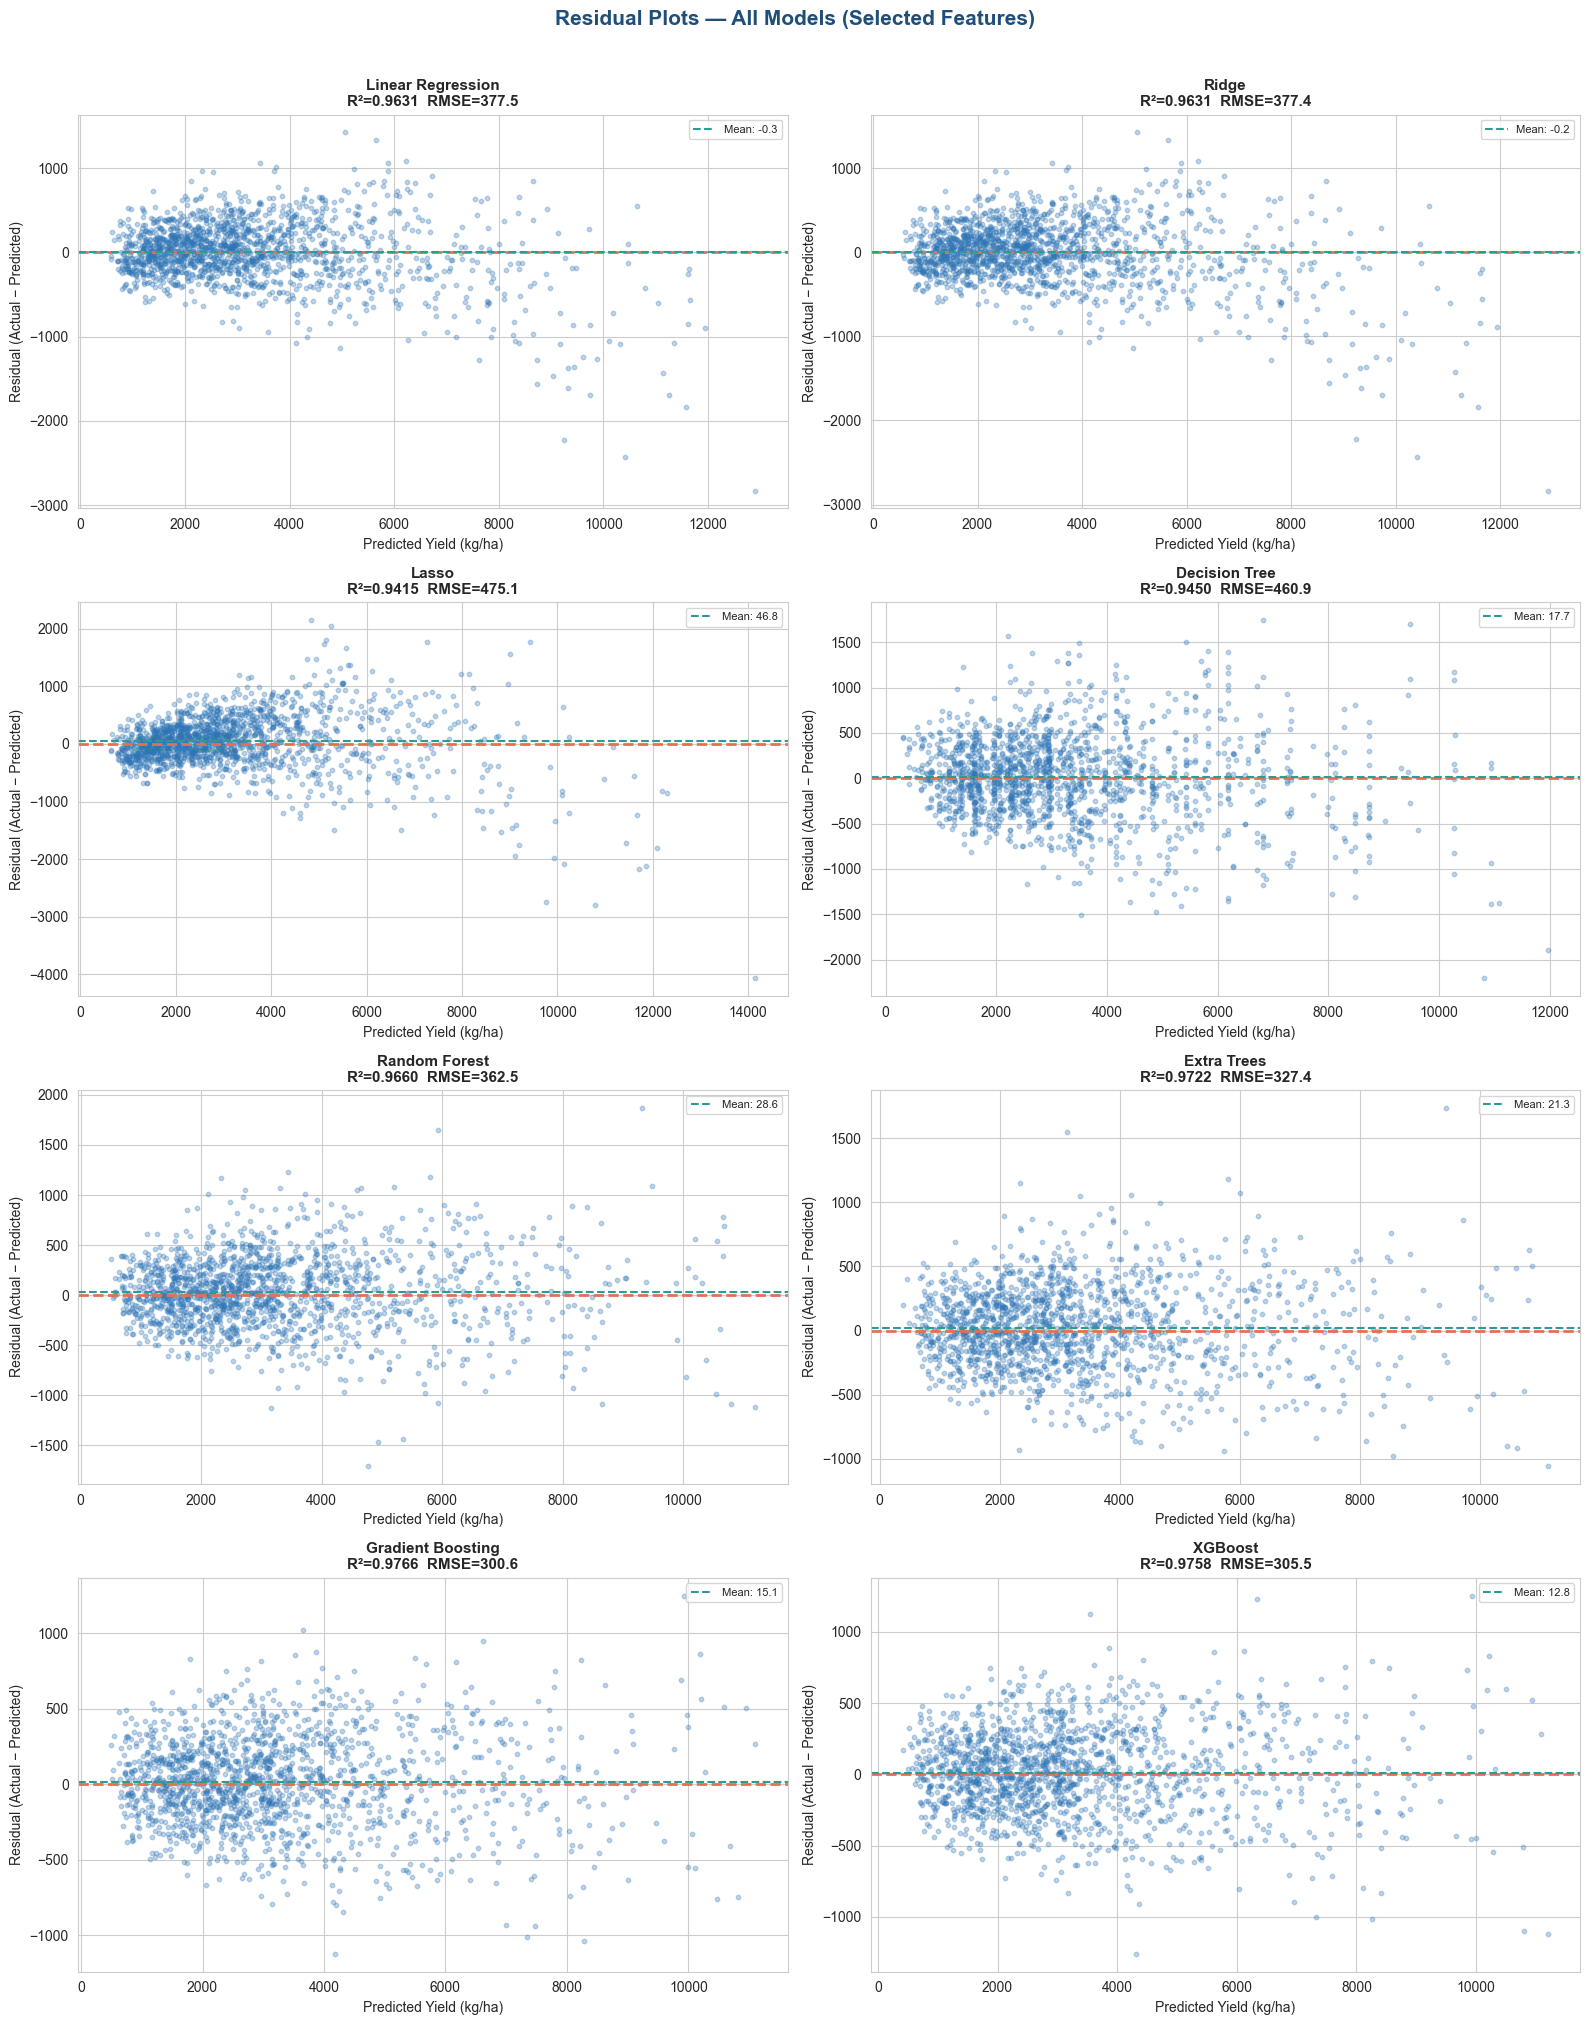

Model saved → zimbabwe_maize_yield_model.pkl

Verification — First 5 Predictions:
    Actual |  Predicted |      Error
-----------------------------------
    8100.3 |     8372.6 |      272.3
    1113.3 |      958.4 |      154.9
    1835.6 |     1802.2 |       33.4
    1233.1 |     1514.5 |      281.4
    1217.0 |     1027.1 |      189.9


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Actual vs Predicted
axes[0].scatter(y_true, y_pred, alpha=0.3, s=10, color='#2E75B6')
lims = [y_true.min(), y_true.max()]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Yield (kg/ha)')
axes[0].set_ylabel('Predicted Yield (kg/ha)')
axes[0].set_title('Actual vs Predicted\nGradient Boosting (Selected Features)',
                   fontweight='bold')
axes[0].legend()
r2   = sel_results[best_sel_name]['Test R²']
rmse = sel_results[best_sel_name]['Test RMSE']
mae  = sel_results[best_sel_name]['Test MAE']
axes[0].text(0.05, 0.92, f'R²={r2}  RMSE={rmse}  MAE={mae}',
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#EAF2FB'))

# Residuals vs Predicted
axes[1].scatter(y_pred, resids, alpha=0.3, s=10, color='#2E75B6')
axes[1].axhline(0, color='#E76F51', lw=2, ls='--')
axes[1].axhline(resids.mean(), color='#2A9D8F', lw=1.5, ls='--',
                label=f'Mean residual: {resids.mean():.1f}')
axes[1].set_xlabel('Predicted Yield (kg/ha)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residuals vs Predicted\nGradient Boosting (Selected Features)',
                   fontweight='bold')
axes[1].legend()

# Residual distribution
sns.histplot(resids, bins=50, kde=True, color='#1F4E79', ax=axes[2])
axes[2].axvline(0, color='#E76F51', lw=2, ls='--')
axes[2].axvline(resids.mean(), color='#2A9D8F', lw=1.5, ls='--',
                label=f'Mean: {resids.mean():.1f}')
axes[2].set_xlabel('Residual (kg/ha)')
axes[2].set_title('Residual Distribution\nGradient Boosting (Selected Features)',
                   fontweight='bold')
axes[2].legend()

plt.suptitle('Stage 10: Final Model Evaluation — Selected Features',
             fontsize=14, fontweight='bold', color='#1F4E79')
plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# 10b. Residual plots for all models — selected features
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, (name, res) in enumerate(sel_results.items()):
    pipe   = res['pipeline']
    y_pred_all = np.expm1(pipe.predict(X_sel_test))
    resids_all = y_true - y_pred_all

    ax = axes[idx]
    ax.scatter(y_pred_all, resids_all, alpha=0.3, s=10, color='#2E75B6')
    ax.axhline(0, color='#E76F51', lw=2, ls='--')
    ax.axhline(resids_all.mean(), color='#2A9D8F', lw=1.5, ls='--',
               label=f'Mean: {resids_all.mean():.1f}')
    ax.set_title(f'{name}\nR²={res["Test R²"]:.4f}  RMSE={res["Test RMSE"]:.1f}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Yield (kg/ha)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.legend(fontsize=8)

plt.suptitle('Residual Plots — All Models (Selected Features)',
             fontsize=15, fontweight='bold', color='#1F4E79', y=1.01)
plt.tight_layout()
plt.savefig('residual_plots_selected.png', dpi=150, bbox_inches='tight')
plt.show()

# 10c. Save best model
joblib.dump(best_sel_pipe, 'zimbabwe_maize_yield_model.pkl')
print("Model saved → zimbabwe_maize_yield_model.pkl")

# 10d. Verify model loads and predicts correctly
loaded_model = joblib.load('zimbabwe_maize_yield_model.pkl')
test_pred    = np.expm1(loaded_model.predict(X_sel_test[:5]))
test_actual  = np.expm1(y_sel_test[:5])

print("\nVerification — First 5 Predictions:")
print(f"{'Actual':>10} | {'Predicted':>10} | {'Error':>10}")
print("-" * 35)
for a, p in zip(test_actual, test_pred):
    print(f"{a:>10.1f} | {p:>10.1f} | {abs(a-p):>10.1f}")

In [35]:
from sklearn.model_selection import RandomizedSearchCV

# 11a. Define parameter grid
param_grid = {
    'model__n_estimators':      [100, 200, 300, 500],
    'model__learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'model__max_depth':         [3, 4, 5, 6, 7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4, 5],
    'model__subsample':         [0.7, 0.8, 0.9, 1.0],
    'model__max_features':      ['sqrt', 'log2', None],
}


In [36]:
tuning_pipe = Pipeline([
    ('preprocessor', sel_preprocessor),
    ('model',        GradientBoostingRegressor(random_state=42))
])


In [37]:
search = RandomizedSearchCV(
    estimator  = tuning_pipe,
    param_distributions = param_grid,
    n_iter     = 50,
    cv         = kf,
    scoring    = 'r2',
    n_jobs     = -1,
    random_state = 42,
    verbose    = 1,
    refit      = True
)

print("Starting RandomizedSearchCV — 50 iterations × 5 folds = 250 fits...")
search.fit(X_sel_train, y_sel_train)

Starting RandomizedSearchCV — 50 iterations × 5 folds = 250 fits...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Seasonal '
                                                                                'Rainfall '
                                                                                'mm',
                                                                                'Area '
                                                                                'Cultivated '
                                                                                'ha',
                                                                                'AEZ_Ordinal',
                                                                                'Improved '
                                                                                'Seed',
                                                                                'Fertilizer '
                                                                                'kg '
                                                                                'ha',
                                                                                'Irrigat...
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 4, 5, 6, 7],
                                        'model__max_features': ['sqrt', 'log2',
                                                                None],
                                        'model__min_samples_leaf': [1, 2, 4, 5],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [38]:
print(f"\nBest CV R²:  {search.best_score_:.4f}")
print(f"\nBest Parameters:")
for k, v in search.best_params_.items():
    print(f"  {k:<35} {v}")



Best CV R²:  0.9578

Best Parameters:
  model__subsample                    0.8
  model__n_estimators                 500
  model__min_samples_split            5
  model__min_samples_leaf             4
  model__max_features                 sqrt
  model__max_depth                    3
  model__learning_rate                0.05


In [39]:
best_tuned = search.best_estimator_
y_pred_tuned = np.expm1(best_tuned.predict(X_sel_test))
y_true_vals  = np.expm1(y_sel_test)

rmse_tuned = np.sqrt(mean_squared_error(y_true_vals, y_pred_tuned))
mae_tuned  = mean_absolute_error(y_true_vals, y_pred_tuned)
r2_tuned   = r2_score(y_true_vals, y_pred_tuned)

print(f"\nTuned Model — Test Performance:")
print(f"  R²:   {r2_tuned:.4f}")
print(f"  RMSE: {rmse_tuned:.2f}")
print(f"  MAE:  {mae_tuned:.2f}")



Tuned Model — Test Performance:
  R²:   0.9775
  RMSE: 294.97
  MAE:  233.38


In [40]:
print(f"\nImprovement over baseline:")
print(f"  R²   : {sel_results['Gradient Boosting']['Test R²']:.4f} → {r2_tuned:.4f}  ({r2_tuned - sel_results['Gradient Boosting']['Test R²']:+.4f})")
print(f"  RMSE : {sel_results['Gradient Boosting']['Test RMSE']:.2f}  → {rmse_tuned:.2f}  ({rmse_tuned - sel_results['Gradient Boosting']['Test RMSE']:+.2f})")
print(f"  MAE  : {sel_results['Gradient Boosting']['Test MAE']:.2f}  → {mae_tuned:.2f}  ({mae_tuned - sel_results['Gradient Boosting']['Test MAE']:+.2f})")

# 11g. Save tuned model
joblib.dump(best_tuned, 'zimbabwe_maize_yield_tuned.pkl')
print("\nTuned model saved → zimbabwe_maize_yield_tuned.pkl")


Improvement over baseline:
  R²   : 0.9766 → 0.9775  (+0.0009)
  RMSE : 300.55  → 294.97  (-5.58)
  MAE  : 235.53  → 233.38  (-2.15)

Tuned model saved → zimbabwe_maize_yield_tuned.pkl


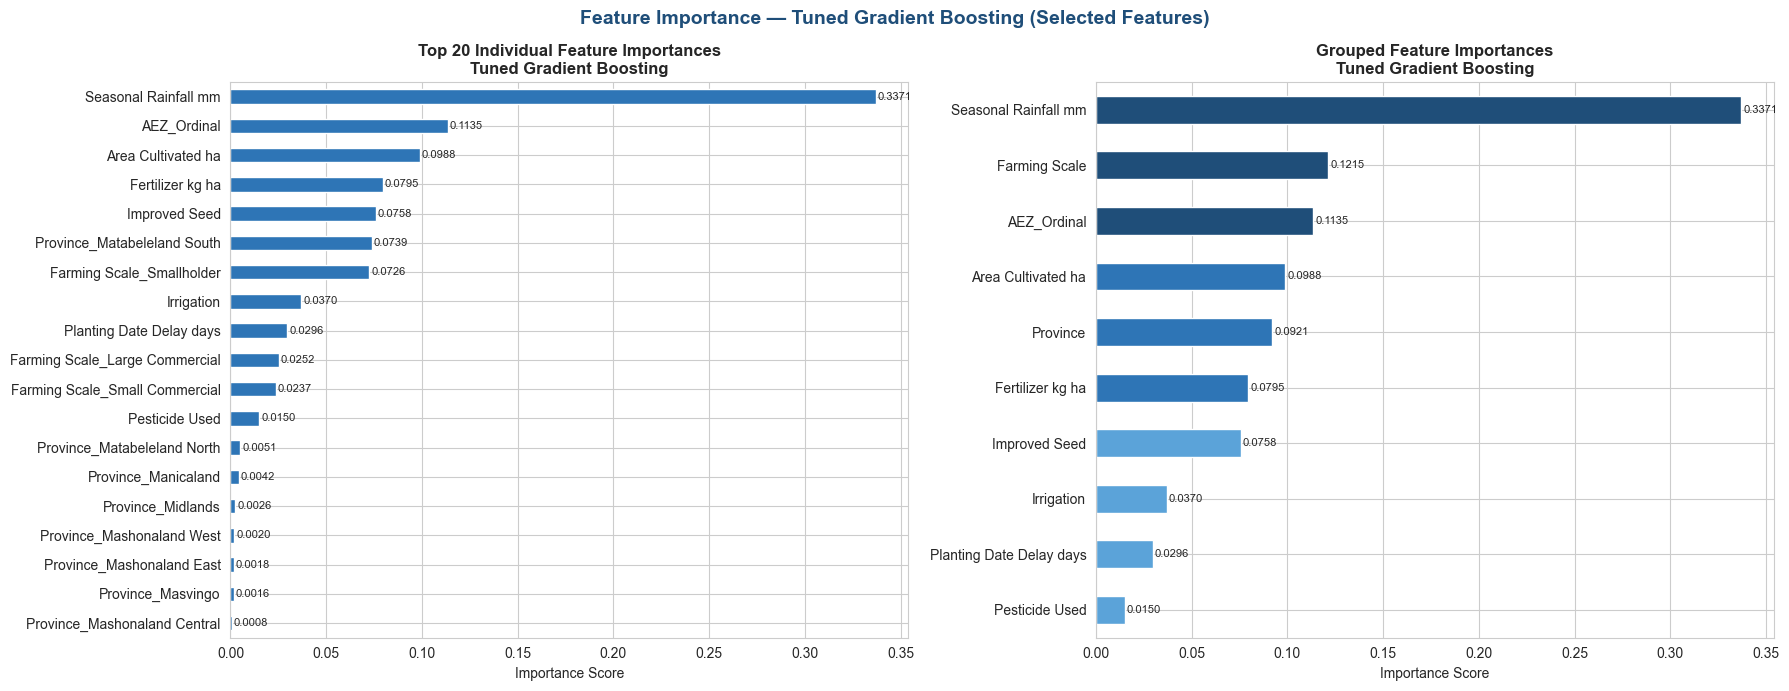

Grouped Feature Importance Ranking — Tuned Model:
---------------------------------------------
   1. Seasonal Rainfall mm                0.3371
   2. Farming Scale                       0.1215
   3. AEZ_Ordinal                         0.1135
   4. Area Cultivated ha                  0.0988
   5. Province                            0.0921
   6. Fertilizer kg ha                    0.0795
   7. Improved Seed                       0.0758
   8. Irrigation                          0.0370
   9. Planting Date Delay days            0.0296
  10. Pesticide Used                      0.0150


In [41]:
# Extract feature names after OHE
ohe_features_sel = (best_tuned.named_steps['preprocessor']
                               .named_transformers_['cat']
                               .named_steps['ohe']
                               .get_feature_names_out(cat_sel).tolist())
all_features_sel = num_sel + ohe_features_sel

# Extract importances
importances_tuned = best_tuned.named_steps['model'].feature_importances_
feat_imp_tuned    = pd.Series(importances_tuned, index=all_features_sel).sort_values(ascending=False)

# Grouped importances
grouped_imp_tuned = group_importance(feat_imp_tuned, cat_sel, num_sel)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
feat_imp_tuned.head(20).plot(kind='barh', ax=axes[0], color='#2E75B6')
axes[0].invert_yaxis()
axes[0].set_title('Top 20 Individual Feature Importances\nTuned Gradient Boosting',
                   fontweight='bold', fontsize=12)
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(feat_imp_tuned.head(20)):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

# Grouped
colors = ['#1F4E79' if i < 3 else '#2E75B6' if i < 6 else '#5BA3D9'
          for i in range(len(grouped_imp_tuned))]
grouped_imp_tuned.plot(kind='barh', ax=axes[1], color=colors)
axes[1].invert_yaxis()
axes[1].set_title('Grouped Feature Importances\nTuned Gradient Boosting',
                   fontweight='bold', fontsize=12)
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(grouped_imp_tuned):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Feature Importance — Tuned Gradient Boosting (Selected Features)',
             fontsize=14, fontweight='bold', color='#1F4E79')
plt.tight_layout()
plt.savefig('feature_importance_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranking
print("Grouped Feature Importance Ranking — Tuned Model:")
print("-" * 45)
for rank, (feat, score) in enumerate(grouped_imp_tuned.items(), 1):
    print(f"  {rank:>2}. {feat:<35} {score:.4f}")


In [49]:
import requests

BASE_NGROK = "https://willow-overarch-imaging.ngrok-free.dev"

# Test 1 — local
local = requests.get("http://127.0.0.1:8000/")
print("Local:", local.json())

# Test 2 — tunnel
tunnel = requests.get(BASE_NGROK + "/")
print("Tunnel:", tunnel.json())

# Test 3 — webhook
res = requests.post(
    BASE_NGROK + "/whatsapp",
    data={"Body": "hi", "From": "whatsapp:+263771234567"}
)
print("Webhook Status:", res.status_code)
print("Webhook Response:", res.text[:300])

Local: {'status': 'running', 'platform': 'Zimbabwe Maize Yield Platform'}
Tunnel: {'status': 'running', 'platform': 'Zimbabwe Maize Yield Platform'}
Webhook Status: 200
Webhook Response: <?xml version="1.0" encoding="UTF-8"?><Response><Message>🌽 *Zimbabwe Maize Yield Platform*

Welcome! What would you like to do?

1️⃣  Register as a Farmer
2️⃣  Predict my Maize Yield
3️⃣  Find Buyers
4️⃣  Check Market Prices
5️⃣  Register as a Buyer

Reply with a number (1-5)</Message></Response>


In [46]:
# Run this in Jupyter to delete the bad farmer record
import sqlite3

conn = sqlite3.connect('C:/Users/lesson/OneDrive/Desktop/YIELD/maize_platform.db')
cursor = conn.cursor()

# See all farmers
cursor.execute("SELECT id, full_name, province, farming_scale FROM farmers")
print(cursor.fetchall())

# Delete bad records where province = 'string'
cursor.execute("DELETE FROM farmers WHERE province = 'string'")
conn.commit()

# Verify
cursor.execute("SELECT id, full_name, province, farming_scale FROM farmers")
print("After cleanup:", cursor.fetchall())
conn.close()
print("Done.")

[(1, 'string', 'string', 'string'), (2, 'John Moyo', 'Mashonaland West', 'Smallholder'), (3, 'Big Boss', 'Manicaland', 'Smallholder'), (4, 'Lessonic', 'Manicaland', 'Smallholder')]
After cleanup: [(2, 'John Moyo', 'Mashonaland West', 'Smallholder'), (3, 'Big Boss', 'Manicaland', 'Smallholder'), (4, 'Lessonic', 'Manicaland', 'Smallholder')]
Done.


In [47]:
# ── SEED DATABASE — 500 Buyers + 20 Farmers ───────────────────────────────────
# Run this in Jupyter (maize_env kernel)

import sqlite3
import random
from datetime import datetime, timedelta

DB_PATH = 'C:/Users/lesson/OneDrive/Desktop/YIELD/maize_platform.db'

# ── Data Pools ────────────────────────────────────────────────────────────────
first_names = [
    "John","Mary","Peter","Grace","David","Chipo","Tendai","Rudo",
    "Farai","Tafadzwa","Blessing","Nomsa","Sibongile","Munyaradzi",
    "Tinashe","Rutendo","Tatenda","Simba","Nyasha","Kudakwashe",
    "Tapiwa","Fungai","Chenai","Takudzwa","Tinotenda","Rumbidzai",
    "Prosper","Loveness","Innocent","Patience","Fortune","Shelter",
    "Talent","Praise","Trust","Believe","Ropafadzo","Tariro",
    "Gamuchirai","Shamiso","Zvichapera","Mazvita","Tsungai","Anesu",
    "Taurai","Tawanda","Maidei","Vimbai","Zanele","Nkosi"
]

last_names = [
    "Moyo","Ncube","Dube","Mhlanga","Sibanda","Ndlovu","Nkomo",
    "Muzenda","Chikwanda","Mupambi","Gumbo","Mutasa","Chirwa",
    "Phiri","Banda","Mwale","Zimba","Zulu","Nzou","Makoni",
    "Chikurunhe","Mutsvairo","Hungwe","Mashava","Mabika",
    "Nyambi","Chivasa","Mutizwa","Madziwa","Chigwanda",
    "Munyoro","Sithole","Mpofu","Bhebhe","Tshuma","Mlotshwa",
    "Nyoni","Dlamini","Khumalo","Mthethwa","Zwane","Maseko"
]

companies = [
    "Grain Millers Zimbabwe","GMB Depot","National Foods Ltd",
    "Profeeds Zimbabwe","Agrifoods Pvt Ltd","ZimGrain Traders",
    "Harare Milling Co","Bulawayo Grain Depot","Eastern Highlands Agri",
    "Southern Cross Trading","Farmer Direct Ltd","AgriLink Zimbabwe",
    "Maize Masters Pvt Ltd","ZimHarvest Co","Savanna Grain Traders",
    "Highveld Foods","Midlands Milling","Victoria Falls Agri",
    "Limpopo Grain Co","Zambezi Traders","Kariba Agri Depot",
    "Hwange Food Hub","Gweru Grain Centre","Mutare Agri Co",
    "Masvingo Millers","Chinhoyi Grain Hub","Bindura Foods",
    "Kadoma Agri Depot","Kwekwe Grain Market","Redcliff Millers",
    "Triangle Agri Ltd","Chiredzi Grain Co","Beitbridge Traders",
    "Norton Foods Pvt Ltd","Ruwa Grain Depot","Chitungwiza Agri",
    "Epworth Food Hub","Mazowe Grain Co","Concession Agri",
    "Mvurwi Millers","Centenary Grain Hub","Mt Darwin Foods",
    "Gokwe Agri Centre","Sanyati Grain Co","Murombedzi Traders",
    "Zvishavane Millers","Shurugwi Grain Hub","Mberengwa Agri",
    "Gutu Grain Depot","Zaka Foods Ltd"
]

provinces = [
    "Mashonaland West","Mashonaland East","Mashonaland Central",
    "Manicaland","Masvingo","Midlands",
    "Matabeleland North","Matabeleland South"
]

scales  = ["Smallholder","Small Commercial","Large Commercial"]
aez     = ["I","II","IIb","III","IV","V"]
soils   = ["Sandy Loam","Clay Loam","Sandy","Red Clay"]
variety = ["SC403","SC513","ZM421","ZM521","DKC80-73","Local/OPV"]

# Province → typical price range
price_by_province = {
    "Mashonaland West"   : (0.26, 0.30),
    "Mashonaland East"   : (0.25, 0.29),
    "Mashonaland Central": (0.26, 0.30),
    "Manicaland"         : (0.24, 0.28),
    "Masvingo"           : (0.27, 0.32),
    "Midlands"           : (0.26, 0.31),
    "Matabeleland North" : (0.28, 0.33),
    "Matabeleland South" : (0.29, 0.34),
}

# Province → typical AEZ
province_aez = {
    "Mashonaland West"   : ["II","IIb"],
    "Mashonaland East"   : ["II","IIb"],
    "Mashonaland Central": ["IIb","III"],
    "Manicaland"         : ["I","II"],
    "Masvingo"           : ["IV","V"],
    "Midlands"           : ["III","IV"],
    "Matabeleland North" : ["IV","V"],
    "Matabeleland South" : ["V"],
}

# Province → typical farming scale distribution
province_scale = {
    "Mashonaland West"   : ["Smallholder","Small Commercial","Large Commercial"],
    "Mashonaland East"   : ["Smallholder","Small Commercial","Large Commercial"],
    "Mashonaland Central": ["Smallholder","Small Commercial"],
    "Manicaland"         : ["Smallholder","Small Commercial","Large Commercial"],
    "Masvingo"           : ["Smallholder","Smallholder","Small Commercial"],
    "Midlands"           : ["Smallholder","Small Commercial"],
    "Matabeleland North" : ["Smallholder","Smallholder"],
    "Matabeleland South" : ["Smallholder"],
}

def random_name():
    return f"{random.choice(first_names)} {random.choice(last_names)}"

def random_phone(used):
    while True:
        num = f"+2637{random.randint(10000000, 99999999)}"
        if num not in used:
            used.add(num)
            return num

def random_date(days_back=180):
    return (datetime.now() - timedelta(days=random.randint(0, days_back))
            ).strftime("%Y-%m-%d %H:%M:%S")

# ── Connect to DB ─────────────────────────────────────────────────────────────
conn   = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

used_phones = set()

# Get existing phones
cursor.execute("SELECT phone_number FROM farmers")
for row in cursor.fetchall():
    used_phones.add(row[0])
cursor.execute("SELECT phone_number FROM buyers")
for row in cursor.fetchall():
    used_phones.add(row[0])

print(f"Existing phones loaded: {len(used_phones)}")

# ── INSERT 20 FARMERS ─────────────────────────────────────────────────────────
farmers_data = []
for i in range(20):
    prov    = random.choice(provinces)
    scale   = random.choice(province_scale[prov])
    aez_val = random.choice(province_aez[prov])

    # Area depends on scale
    if scale == "Smallholder":
        area = round(random.uniform(0.5, 5.0), 2)
    elif scale == "Small Commercial":
        area = round(random.uniform(5.0, 50.0), 2)
    else:
        area = round(random.uniform(50.0, 300.0), 2)

    farmers_data.append((
        random_name(),
        random_phone(used_phones),
        prov,
        scale,
        area,
        aez_val,
        random.choice(soils),
        random.choice(variety),
        random_date(365),
        1
    ))

cursor.executemany("""
    INSERT INTO farmers
    (full_name, phone_number, province, farming_scale,
     area_cultivated_ha, agro_ecological_zone, soil_type,
     maize_variety, registered_at, is_active)
    VALUES (?,?,?,?,?,?,?,?,?,?)
""", farmers_data)

print(f"✅ {len(farmers_data)} farmers inserted.")

# ── INSERT 500 BUYERS ─────────────────────────────────────────────────────────
buyers_data = []
for i in range(500):
    prov        = random.choice(provinces)
    price_range = price_by_province[prov]
    price       = round(random.uniform(*price_range), 3)

    # Quantity depends on buyer type
    buyer_type = random.choice(["individual","small","large"])
    if buyer_type == "individual":
        quantity    = round(random.uniform(500, 5000), 0)
        company     = None
    elif buyer_type == "small":
        quantity    = round(random.uniform(5000, 50000), 0)
        company     = random.choice(companies)
    else:
        quantity    = round(random.uniform(50000, 500000), 0)
        company     = random.choice(companies)

    buyers_data.append((
        random_name(),
        random_phone(used_phones),
        company,
        prov,
        quantity,
        price,
        random_date(180),
        1
    ))

cursor.executemany("""
    INSERT INTO buyers
    (full_name, phone_number, company_name, province,
     quantity_needed, price_offered, registered_at, is_active)
    VALUES (?,?,?,?,?,?,?,?)
""", buyers_data)

print(f"✅ {len(buyers_data)} buyers inserted.")

conn.commit()

# ── Verify ────────────────────────────────────────────────────────────────────
cursor.execute("SELECT COUNT(*) FROM farmers WHERE is_active=1")
print(f"\nTotal active farmers : {cursor.fetchone()[0]}")

cursor.execute("SELECT COUNT(*) FROM buyers WHERE is_active=1")
print(f"Total active buyers  : {cursor.fetchone()[0]}")

cursor.execute("""
    SELECT province, COUNT(*) as count
    FROM farmers WHERE is_active=1
    GROUP BY province ORDER BY count DESC
""")
print("\nFarmers by Province:")
for row in cursor.fetchall():
    print(f"  {row[0]:<25} {row[1]}")

cursor.execute("""
    SELECT province, COUNT(*) as count,
           ROUND(AVG(price_offered),3) as avg_price
    FROM buyers WHERE is_active=1
    GROUP BY province ORDER BY count DESC
""")
print("\nBuyers by Province (with avg price):")
for row in cursor.fetchall():
    print(f"  {row[0]:<25} {row[1]} buyers | avg ${row[2]}/kg")

cursor.execute("""
    SELECT farming_scale, COUNT(*) as count
    FROM farmers WHERE is_active=1
    GROUP BY farming_scale
""")
print("\nFarmers by Scale:")
for row in cursor.fetchall():
    print(f"  {row[0]:<20} {row[1]}")

conn.close()
print("\n✅ Database seeded successfully!")

Existing phones loaded: 7
✅ 20 farmers inserted.
✅ 500 buyers inserted.

Total active farmers : 23
Total active buyers  : 504

Farmers by Province:
  Manicaland                8
  Matabeleland South        3
  Matabeleland North        3
  Midlands                  2
  Masvingo                  2
  Mashonaland West          2
  Mashonaland Central       2
  Mashonaland East          1

Buyers by Province (with avg price):
  Masvingo                  72 buyers | avg $0.295/kg
  Midlands                  65 buyers | avg $0.287/kg
  Mashonaland West          65 buyers | avg $0.28/kg
  Matabeleland North        63 buyers | avg $0.308/kg
  Mashonaland East          61 buyers | avg $0.27/kg
  Manicaland                61 buyers | avg $0.271/kg
  Matabeleland South        60 buyers | avg $0.313/kg
  Mashonaland Central       57 buyers | avg $0.28/kg

Farmers by Scale:
  Large Commercial     2
  Small Commercial     7
  Smallholder          14

✅ Database seeded successfully!


In [48]:
import requests

# First test local API is working
local = requests.get("http://127.0.0.1:8000/")
print("Local API:", local.json())

# Then test ngrok tunnel
tunnel = requests.get("https://willow-overarch-imaging.ngrok-free.dev/")
print("Tunnel:", tunnel.json())

# Then test webhook
webhook = requests.post(
    "https://willow-overarch-imaging.ngrok-free.dev/whatsapp",
    data={"Body": "hi", "From": "whatsapp:+263771234567"}
)
print("Webhook status:", webhook.status_code)
print("Webhook response:", webhook.text[:200])

Local API: {'status': 'running', 'platform': 'Zimbabwe Maize Yield Platform'}
Tunnel: {'status': 'running', 'platform': 'Zimbabwe Maize Yield Platform'}
Webhook status: 200
Webhook response: <?xml version="1.0" encoding="UTF-8"?><Response><Message>🌽 *Zimbabwe Maize Yield Platform*

Welcome! What would you like to do?

1️⃣  Register as a Farmer
2️⃣  Predict my Maize Yield
3️⃣  Find Buyers



In [50]:
# Run in Jupyter
import os

session_file = 'C:/Users/lesson/OneDrive/Desktop/YIELD/sessions.json'
if os.path.exists(session_file):
    os.remove(session_file)
    print("sessions.json deleted.")
else:
    print("No session file found.")

sessions.json deleted.


In [51]:
# Run in Jupyter — simulates WhatsApp messages
import sys
sys.path.insert(0, 'C:/Users/lesson/OneDrive/Desktop/YIELD')

from whatsapp_bot import handle_message

# Simulate conversation
test_number = "+263771234567"

print("="*50)
print("MSG: hi")
print("BOT:", handle_message(test_number, "hi"))

print("\nMSG: 4")
print("BOT:", handle_message(test_number, "4"))

print("\nMSG: menu")
print("BOT:", handle_message(test_number, "menu"))

MSG: hi
BOT: 🌽 *Zimbabwe Maize Yield Platform*

Welcome! What would you like to do?

1️⃣  Register as a Farmer
2️⃣  Predict my Maize Yield
3️⃣  Find Buyers
4️⃣  Check Market Prices
5️⃣  Register as a Buyer

Reply with a number (1-5)

MSG: 4
BOT: 💰 *Current Maize Market Prices*

📍 Mashonaland West
   $0.35/kg  |  $350.0/t

📍 Mashonaland East
   $0.27/kg  |  $270.0/t

📍 Mashonaland Central
   $0.27/kg  |  $270.0/t

📍 Manicaland
   $0.26/kg  |  $260.0/t

📍 Masvingo
   $0.29/kg  |  $290.0/t

📍 Midlands
   $0.28/kg  |  $280.0/t

📍 Matabeleland North
   $0.3/kg  |  $300.0/t

📍 Matabeleland South
   $0.31/kg  |  $310.0/t

Reply *menu* to go back.

MSG: menu
BOT: 🌽 *Zimbabwe Maize Yield Platform*

Welcome! What would you like to do?

1️⃣  Register as a Farmer
2️⃣  Predict my Maize Yield
3️⃣  Find Buyers
4️⃣  Check Market Prices
5️⃣  Register as a Buyer

Reply with a number (1-5)


In [52]:
# Run in Jupyter
import requests

res = requests.post(
    "https://willow-overarch-imaging.ngrok-free.dev/whatsapp",
    data={"Body": "hi", "From": "whatsapp:+263771234567"}
)
print("Status:", res.status_code)
print("Response:", res.text[:500])

SSLError: HTTPSConnectionPool(host='willow-overarch-imaging.ngrok-free.dev', port=443): Max retries exceeded with url: /whatsapp (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)')))